# Assignment 1 - PHYS 512

## Question 1 - Roundoff error in the harmonic oscillator

Part a)

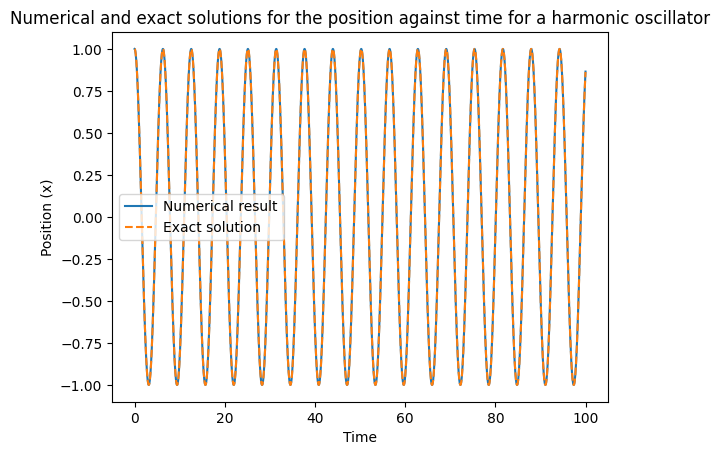

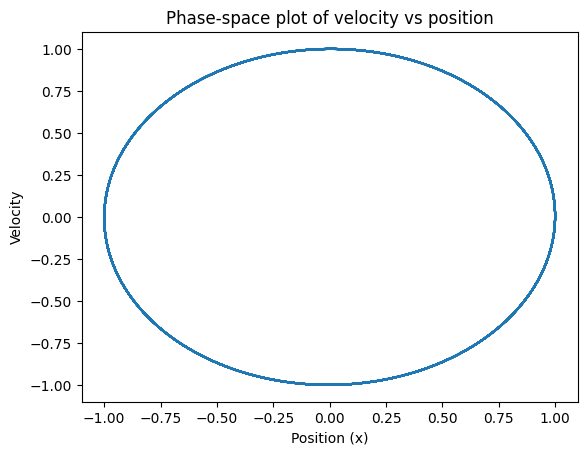

In [162]:
import numpy as np
import matplotlib.pyplot as plt

omega = 1 # value of omega given in the problem

# Initial conditions
x0 = 1
v0 = 0

t_final = 100 # end time
delta_t = 0.01 # step size
timesteps = np.arange(0, t_final+delta_t, delta_t) # array of timesteps

# Semi-implicit Euler method implementation
def semi_implicit_Euler(x0, v0, omega, delta_t, timesteps):
    
    # Arrays of zeros that will contain the updated values for v and x
    v = np.zeros(len(timesteps))
    x = np.zeros(len(timesteps))

    v[0] = v0 # initialize initial value for v
    x[0] = x0 # initialize initial value for x

    # at each timestep, calculate the new v and x (using the update equations provided)
    for i in range(1, len(timesteps)):
        v[i] = v[i-1] - (omega**2)*x[i-1]*delta_t
        x[i] = x[i-1] + v[i]*delta_t # calculate new x value based on newly calculated v value
    return x, v

# Call the semi-implicit Euler method with initial conditions and values
x, v = semi_implicit_Euler(x0, v0, omega, delta_t, timesteps)

# Plot the position vs time for numerical and exact solutions
plt.plot(timesteps, x, label='Numerical result')
plt.plot(timesteps, np.cos(timesteps), label='Exact solution', linestyle='--')
plt.xlabel('Time')
plt.ylabel('Position (x)')
plt.title('Numerical and exact solutions for the position against time for a harmonic oscillator')
plt.legend()
plt.show()

# Plot a phase-space plot
plt.plot(x, v)
plt.xlabel('Position (x)')
plt.ylabel('Velocity')
plt.title('Phase-space plot of velocity vs position')
plt.show()


From the plot of $x$ as a function of time for both the numerical result and the exact solution, it is clear that both solutions are very close (they seem to overlap very closely). Therefore, we can conclude that with a step size of only $dt=0.01$, the semi-implicit Euler method is already a very good approximation of the exact solution.

For the phase-space plot (velocity against position), I expected the solution to trace out a circle. Indeed, this is the case because for our exact solution, we have $x(t) = cos(t)$, and $v(t) = \frac{dx}{dt} = -sin(t)$. Therefore, it is clear that as the time goes from 0 to $2π$, the position (x) and velocity will oscillate between values of -1 and 1, with one reaching a maximum/minimum of 1 or -1 (respectively) as the other reaches 0. This forms a circle, as can  be seen from considering the fact that the equation $x^2 + v^2 = 1$ is satisfied. The reason that we are observing small deviations from a perfect circle in the plot is simply because of small numerical errors in the integration.

Part b)

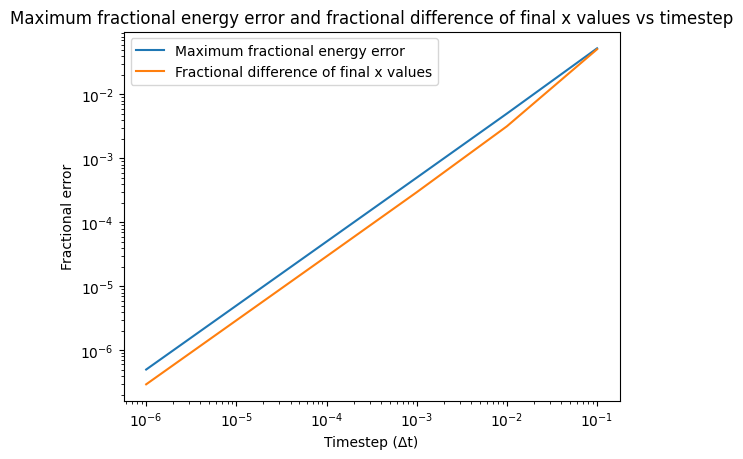

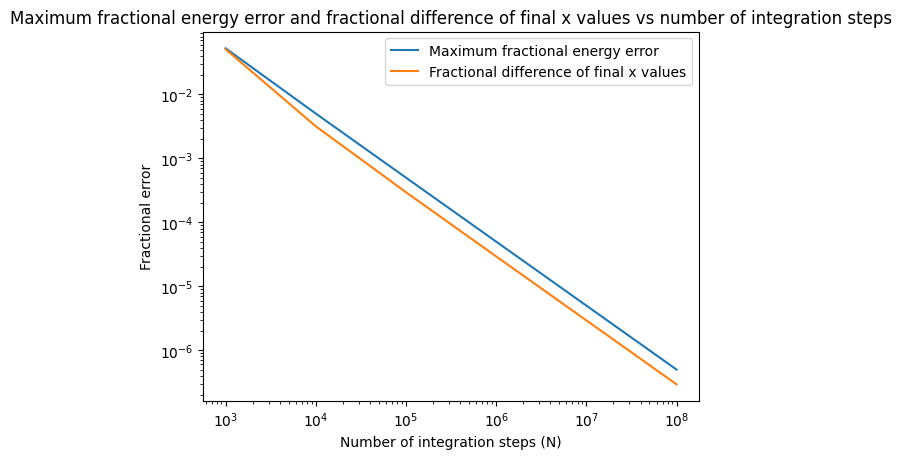

In [ ]:
omega = 1 # value of omega given in the problem

# Initial conditions
x0 = 1
v0 = 0

t_final = 100 # final time
delta_t = np.array([0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1]) # different step sizes (stops at 1e-6 since smaller step sizes started causing memory issues)

# Declare arrays of zeros that will contain the errors and the number of steps
max_energy_err = np.zeros(len(delta_t))
x_err = np.zeros(len(delta_t))
N = np.zeros(len(delta_t))

for i, dt in enumerate(delta_t):
    timesteps = np.arange(0, t_final+dt, dt) # get array of timesteps based on current dt
    N[i] = t_final/dt # calculate number of steps

    # Call semi-implicit Euler method with current dt
    x, v = semi_implicit_Euler(x0, v0, omega, dt, timesteps)

    # Calculate the fractional difference between the obtained final value of x and the analytic prediction
    x_err[i] = np.abs((x[-1] - np.cos(t_final))/np.cos(t_final))

    # Calculate the total energy of the oscillator at each integration step
    energy = (1/2)*(v**2) + (1/2)*(omega**2)*(x**2)

    # Keep the maximum fractional energy error for the current dt
    max_energy_err[i] = np.max(np.abs((energy - energy[0])/energy[0]))

# Plotting the maximum fractional energy error and the fractional difference of calculated and actual final x values against the timestep (dt)
plt.loglog(delta_t, max_energy_err, label='Maximum fractional energy error')
plt.loglog(delta_t, x_err, label='Fractional difference of final x values')
plt.xlabel('Timestep (Δt)')
plt.ylabel('Fractional error')
plt.title("Maximum fractional energy error and fractional difference of final x values vs timestep")
plt.legend()
plt.show()

# Plotting the maximum fractional energy error and the fractional difference of calculated and actual final x values against the number of integration steps (N)
plt.loglog(N, max_energy_err, label='Maximum fractional energy error')
plt.loglog(N, x_err, label='Fractional difference of final x values')
plt.xlabel('Number of integration steps (N)')
plt.ylabel('Fractional error')
plt.title("Maximum fractional energy error and fractional difference of final x values vs number of integration steps")
plt.legend()
plt.show()

From the plots above, we can observe linear slopes in the log-log plots, meaning that the fractional errors follow a power law relationship with both the timestep and the number of integration steps. Indeed, from the first plot, it seems that the slope on the log-log plot is of approximately 1. Therefore, we can say that both the maximum fractional energy error and the fractional difference of the final x values scale as $Δt$. From the second plot, we can observe a slope of approximately -1 on the log-log plot. Therefore, we can say that both the maximum fractional energy error and the fractional difference of the final x values scale as $N^{-1}$. From this, we can conclude that the semi-implicit Euler method is first order accurate.

Part c)

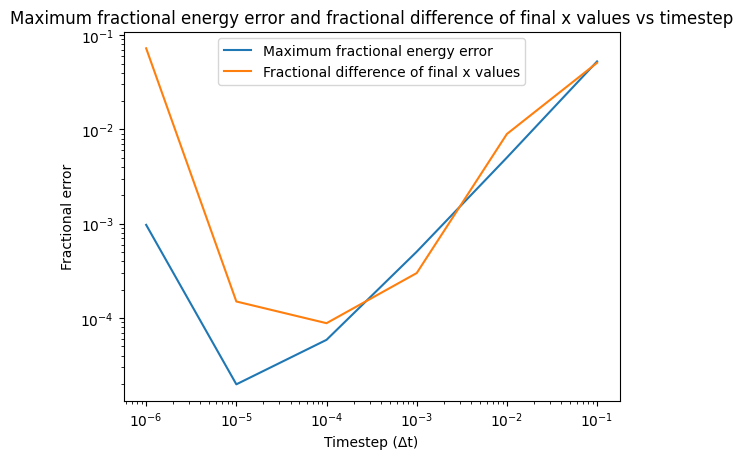

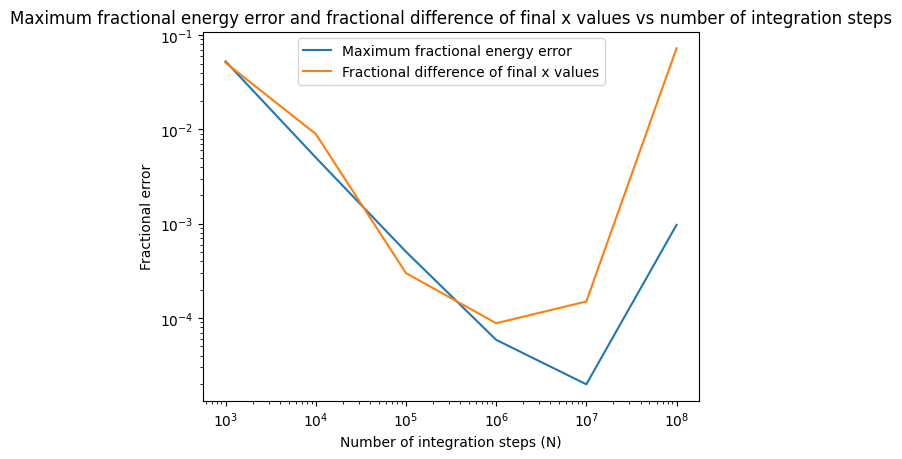

In [164]:
# Code copied from part b), with "np.float32()" added for each number and "dtype=np.float32" added for numpy arrays

omega = np.float32(1) # value of omega given in the problem

# Initial conditions
x0 = np.float32(1)
v0 = np.float32(0)

t_final = np.float32(100) # final time
delta_t = np.array([0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1], dtype=np.float32) # different step sizes (stops at 1e-6 since smaller step sizes started causing memory issues)

# Declare arrays of zeros that will contain the errors and the number of steps
max_energy_err = np.zeros(len(delta_t), dtype=np.float32)
x_err = np.zeros(len(delta_t), dtype=np.float32)
N = np.zeros(len(delta_t), dtype=np.float32)

# Semi-implicit Euler method implementation (adapted for float32)
def semi_implicit_Euler(x0, v0, omega, delta_t, timesteps):
    
    # Arrays of zeros that will contain the updated values for v and x
    v = np.zeros(len(timesteps), dtype=np.float32)
    x = np.zeros(len(timesteps), dtype=np.float32)

    v[0] = v0 # initialize initial value for v
    x[0] = x0 # initialize initial value for x

    # at each timestep, calculate the new v and x (using the update equations provided)
    for i in range(1, len(timesteps)):
        v[i] = np.float32(v[i-1] - (omega**2)*x[i-1]*delta_t)
        x[i] = np.float32(x[i-1] + v[i]*delta_t) # calculate new x value based on newly calculated v value
    return x, v

for i, dt in enumerate(delta_t):
    timesteps = np.arange(0, t_final+dt, dt, dtype=np.float32) # get array of timesteps based on current dt
    N[i] = np.float32(t_final/dt) # calculate number of steps

    # Call semi-implicit Euler method with current dt
    x, v = semi_implicit_Euler(x0, v0, omega, dt, timesteps)

    # Calculate the fractional difference between the obtained final value of x and the analytic prediction
    x_err[i] = np.float32(np.abs((x[-1] - np.cos(t_final))/np.cos(t_final)))

    # Calculate the total energy of the oscillator at each integration step
    energy = np.float32((np.float32(1/2))*(v**2) + (np.float32(1/2))*(omega**2)*(x**2))

    # Keep the maximum fractional energy error for the current dt
    max_energy_err[i] = np.float32(np.max(np.abs((energy - energy[0])/energy[0])))

# Plotting the maximum fractional energy error and the fractional difference of calculated and actual final x values against the timestep (dt)
plt.loglog(delta_t, max_energy_err, label='Maximum fractional energy error')
plt.loglog(delta_t, x_err, label='Fractional difference of final x values')
plt.xlabel('Timestep (Δt)')
plt.ylabel('Fractional error')
plt.title("Maximum fractional energy error and fractional difference of final x values vs timestep")
plt.legend()
plt.show()

# Plotting the maximum fractional energy error and the fractional difference of calculated and actual final x values against the number of integration steps (N)
plt.loglog(N, max_energy_err, label='Maximum fractional energy error')
plt.loglog(N, x_err, label='Fractional difference of final x values')
plt.xlabel('Number of integration steps (N)')
plt.ylabel('Fractional error')
plt.title("Maximum fractional energy error and fractional difference of final x values vs number of integration steps")
plt.legend()
plt.show()

From these results, we observe that the log-log plots do not display linear slopes like in part b). Indeed, for very small step sizes (equivalently, for very large numbers of integration steps), both the maximum fractional energy error and the fractional difference of final x values blow up. This occurs because of the effects of roundoff when the step size is very small, since the large associated number of steps introduces floating-point rounding errors that quickly accumulate (especially visible when using single-precision floating-point numbers). From the plots above, it is difficult to analyze the scaling due to the limited number of points for very small step sizes. However, as described in the problem, we would typically expect an error after N steps to grow as $\sqrt{N}​​ϵ$ for roundoff errors (since they are typically random, and the accumulated error is expected to behave like a random walk), therefore scaling like $Δt^{-1/2}$ (since N scales like $Δt^{-1}$). The slope therefore seems steeper than expected for the plot of the error against the timesteps, but it nonetheless shows how the roundoff errors accumulate as the step size gets smaller, leading to large fractional errors.

## Question 2 - An adaptive Runge-Kutta integrator

115
3.905328150415055e-07


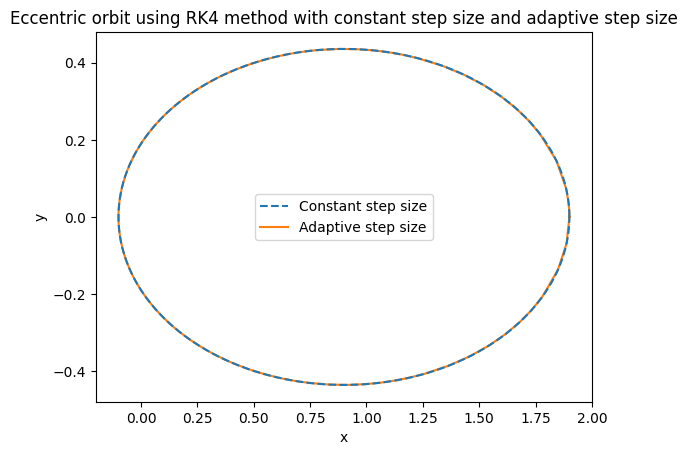

In [166]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

# Derivative equations for an orbit (taken from class example solutions)
def derivs_orbit(t, x):
    rr = (x[0]**2 + x[1]**2)**0.5
    vxdot = -x[0]/rr**3
    vydot = -x[1]/rr**3
    xdot = x[2]
    ydot = x[3]
    return np.array((xdot,ydot,vxdot,vydot))

# Regular Runge-Kutta integrator (taken from class example solutions)
def rk4(nsteps, dt, x0, derivs):
    x = np.zeros((nsteps+1,len(x0)))
    x[0] = x0
    for i in range(1,nsteps+1):    
        f = derivs((i-1)*dt, x[i-1])
        f1 = derivs((i-1)*dt + dt/2, x[i-1] + f*dt/2)
        f2 = derivs((i-1)*dt + dt/2, x[i-1] + f1*dt/2)
        f3 = derivs(i*dt, x[i-1] + f2*dt)
        x[i] = x[i-1] + dt*(f + 2*f1 + 2*f2 + f3)/6
    return x

# Adaptive Runge-Kutta integrator
def adaptive_rk4(t_final, dt, x, t, derivs, tol):
    xtemp_1 = rk4(1, dt, x[-1], derivs) # RK4 step with current step size
    xtemp_2 = rk4(2, dt/2, x[-1], derivs) # two RK4 steps with half the step size
    diff = np.abs(xtemp_2[-1]-xtemp_1[-1]) # compute the difference between the two state vectors
    err = np.sqrt(diff[0]**2 + diff[1]**2 + diff[2]**2 + diff[3]**2) / np.sqrt(xtemp_2[-1,0]**2 + xtemp_2[-1,1]**2 + xtemp_2[-1,2]**2 + xtemp_2[-1,3]**2) # calculate the relative error (magnitude of difference between two estimates / magnitude of the better estimate)
    if (err < tol):
        x.append(xtemp_2[-1]) # once we have reached a small enough error, keep the result found
        t.append(t[-1] + dt) # update the time based on our last step size
        if (np.abs((t_final-t[-1])) < 1e-15):
            return x # if we have reached our final time, return the result (integration is done)
        elif ((t_final-t[-1]) < dt*2):
            dt = t_final - t[-1] # calculate required final step size
            return adaptive_rk4(t_final, dt, x, t, derivs, tol) # for the last step, ensure to end exactly at t=2*pi
        else:
            return adaptive_rk4(t_final, dt*2, x, t, derivs, tol) # increasing the step size by a factor of 2 for the next step
    else:
        return adaptive_rk4(t_final, dt/2, x, t, derivs, tol) # smaller h that will be used in the next while loop iteration in the case where the error is higher than the tolerance

# Define starting parameters
e = 0.9 # eccentricity
nsteps = 5000 # number of steps
t_final = 2*np.pi # end time
dt = t_final / nsteps # step size
t = np.arange(nsteps+1)*dt
tol = 1e-6 # set tolerance
x_start = np.array((1+e, 0, 0, np.sqrt((2/(1+e))-1)))

# Compute the orbit with set initial conditions
x = rk4(nsteps, dt, x_start, derivs_orbit)

# Compute orbit with adaptive step size
time = [0] # start time
x_ad_rk = [x_start] # initial state
x2 = adaptive_rk4(t_final, dt, x_ad_rk, time, derivs_orbit, tol) # call adaptive-step-size RK4 integrator
x2 = np.array(x2) # turn into numpy array

print(len(x2)-1) # number of steps required for 10^-6 accuracy using adaptive step size
y_err = np.abs(x[-1,1]-x_start[1]) # compute the difference between the computed y and the real value (y=0) after time 2*pi
y_err_adaptive = np.abs(x2[-1,1]-x_start[1])
print(y_err) # accuracy obtained with the constant step size RK4 integrator

# Plot ellipses obtained using both methods
plt.plot(x[:,0], x[:,1], label='Constant step size', zorder=2, linestyle='--')
plt.plot(x2[:,0], x2[:,1], label='Adaptive step size', zorder=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Eccentric orbit using RK4 method with constant step size and adaptive step size")
plt.legend()
plt.show()

For a full $e = 0.9$ orbit, the adaptive-step-size RK4 integrator required around 115 steps in order to get an accuracy of $10^{-6}$. On the other hand, the RK4 integrator with constant step size required approximately at least 5000 steps in order to reach an accuracy of around $10^{-6}$. Therefore, the number of steps required to achieve the same accuracy was an order of magnitude higher for the RK4 integrator with constant step size compared to the number of steps required for the adaptive step size method (in this case, it required around 43 times more steps).